In [ ]:
# creation d'un data frame apartir des donnees groupee
rfm = groupedRdd.map(lambda elt: (elt[0],elt[1][0],elt[1][1],elt[1][2]))\
    .toDF(['Customer','Recence','Frequence','Monetary'])
rfm.show()

In [ ]:
def getRfmScore(dataframe):
    df_ = dataframe
    # Calculating the quantiles
    recencySplits = (df_.approxQuantile("Recence",[0.0,0.25,0.5,0.75,1.0],0.1))
    frequencySplit = (df_.approxQuantile("Frequence",[0.0,0.25,0.5,0.75,1.0],0.1))
    monetarySplit = df_.approxQuantile("Monetary",[0.0,0.25,0.5,0.75,1.0],0.1)
    print('RFM splits:',{
        'recency': recencySplits, 'frequency': frequencySplit, 'monetary': monetarySplit
    })
    #segmenting the values accordingly
    recencyBucket = Bucketizer(splits=(recencySplits),inputCol="Recence",outputCol="recence_score")
    frequencyBucket = Bucketizer(splits=frequencySplit,inputCol="Frequence",outputCol="frequence_score")
    monetaryBucket = Bucketizer(splits=monetarySplit,inputCol="Monetary",outputCol="monetary_score")
    df_ = recencyBucket.transform(df_)
    df_ = frequencyBucket.transform(df_)
    df_ = monetaryBucket.transform(df_)
    # create the rfm score which is the concatenation of the 3 values R, F, M
    df_ = df_.withColumn("RFM_SCORE", concat_ws("", df_["recence_score"].cast("int").cast("string"),
                                                 df_["frequence_score"].cast("int").cast("string"),
                                                 df_["monetary_score"].cast("int").cast("string")
                                                )
                        )

    return df_

In [ ]:
rfmScores = getRfmScore(rfm)

RFM splits: {'recency': [1.0, 29.0, 78.0, 175.0, 297.0], 'frequency': [9.0, 46.0, 129.0, 277.0, 3756.0], 'monetary': [12916.0, 40536.0, 97131.0, 204020.0, 3649692.0]}


In [ ]:
rfmScores.show(5)

+-----------------+-------+---------+--------+-------------+---------------+--------------+---------+
|         Customer|Recence|Frequence|Monetary|recence_score|frequence_score|monetary_score|RFM_SCORE|
+-----------------+-------+---------+--------+-------------+---------------+--------------+---------+
|      VISHA DEVAN|     41|      766|692446.0|          1.0|            3.0|           3.0|      133|
|KALAIVANI PERMALU|     98|      636|379736.0|          2.0|            3.0|           3.0|      233|
|     BISSY SKARIA|     66|       78| 55192.0|          1.0|            1.0|           1.0|      111|
|          AANCHOL|    259|        9| 26065.0|          3.0|            0.0|           0.0|      300|
| PUVANES GANNASIN|    165|      129| 89770.0|          2.0|            2.0|           1.0|      221|
+-----------------+-------+---------+--------+-------------+---------------+--------------+---------+
only showing top 5 rows



In [ ]:
def matchSegment(value, segMap):
    for pattern in segMap:
        regex = re.compile(pattern)
        if regex.match(value):
            return segMap[pattern]
    return value

# Define the segment map
segMap = {
    r'^[0-1][3-4][3-4]$' : 'Champions',
    r'^[0-4][3-4][0-4]$' : 'Loyal',
    r'^[0-2]2[0-4]$' : 'Prometteur',
    r'^[0-1][0-2]{2}$' : 'Rookie',
    r'^[2-3][0-2][3-4]$': 'High value',
    r'^[3-4][0-2][0-4]$': 'Dormant',
    r'^[0-4][0-1][0-2]$' : 'En risque',
}

# Create a UDF to replace the values based on the segment map dictionary
udf_replace = F.udf(lambda x: matchSegment(x, segMap))

# Apply the UDF to the RFM_SCORE column and create a new column called 'segment'
rfmMap = rfmScores.withColumn('segment', udf_replace(F.col('RFM_SCORE')))


In [ ]:
rfmMap.sort("segment").write.mode('overwrite').csv("Data/processed/",header = True)

### Segmentation Map visualisation

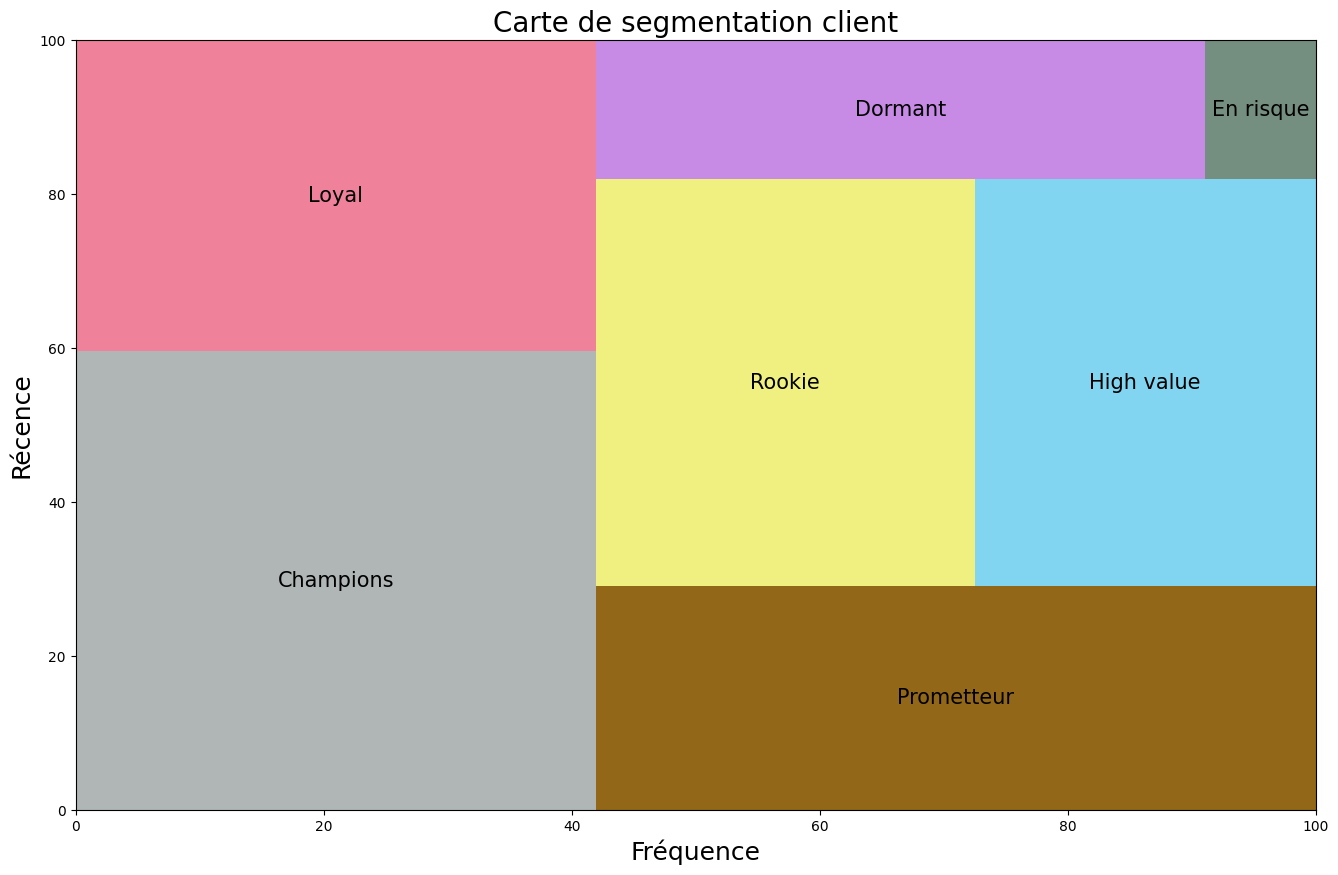

In [ ]:
# Transformer en pandas DF pour visualiser les donnees
pandasRfmDf = rfmMap.sort("segment").toPandas()

segments = pandasRfmDf["segment"].value_counts().sort_values(ascending = False)

fig = plt.gcf()
ax = fig.add_subplot()
fig.set_size_inches(16, 10)
squarify.plot(
    sizes=segments,
    label=[label for label in segMap.values()],
    color=[
        "#AFB6B5",
        "#F0819A",
        "#926717",
        "#F0F081",
        "#81D5F0",
        "#C78BE5",
        "#748E80",
        "#FAAF3A",
        "#7B8FE4",
        "#86E8C0",
    ],
    pad=False,
    bar_kwargs={"alpha": 1},
    text_kwargs={"fontsize": 15},
)

plt.title("Carte de segmentation client", fontsize=20)
plt.xlabel("Fréquence", fontsize=18)
plt.ylabel("Récence", fontsize=18)
plt.show()


In [ ]:
pandasRfmDf.head(20)

,Customer,Recence,Frequence,Monetary,recence_score,frequence_score,monetary_score,RFM_SCORE,segment
0,VISHA DEVAN,41,766,692446.0,1.0,3.0,3.0,133,Champions
1,MULBERRIES BOUTIQUE,39,3756,3649692.0,1.0,3.0,3.0,133,Champions
2,DANESHWARY RAMAR,4,281,218710.0,0.0,3.0,3.0,033,Champions
3,RINA THAKURTA,36,296,412188.0,1.0,3.0,3.0,133,Champions
4,PUNITHAVATHY KARUPIAH,35,284,270416.0,1.0,3.0,3.0,133,Champions
5,VAHARSHA BOUTIQUE,48,1445,1290440.0,1.0,3.0,3.0,133,Champions
6,FUSION FASHIONS CORP.,22,835,621487.0,0.0,3.0,3.0,033,Champions
7,SHILPI KUMARI,29,807,533130.0,1.0,3.0,3.0,133,Champions
8,IBRAHIM MAFTHOOH(JANASYA.IN),27,480,430850.0,0.0,3.0,3.0,033,Champions
9,AVIN,1,634,423581.0,0.0,3.0,3.0,033,Champions


In [ ]:
X = pandasRfmDf[['recence_score','frequence_score']]
labels = pandasRfmDf['segment']
results = {
    'Nombre d\'Observations': [X.shape[0]],
    'Nombre de Segment': [labels.nunique()],
    'Silouhette score': [round(silhouette_score(X,labels),3)],
    'Calinski Harabasz Score': [round(calinski_harabasz_score(X,labels),3)],
    'Davies Bouldin Score': [round(davies_bouldin_score(X,labels),3)]
}

df_results = pd.DataFrame(results)
df_results.head().T


,0
Nombre d'Observations,124.000
Nombre de Segment,7.000
Silouhette score,0.441
Calinski Harabasz Score,93.824
Davies Bouldin Score,0.818


## Analyse des segments

In [ ]:
pandasRfmDf[['Recence','Monetary','Frequence','segment']]\
.groupby('segment')\
.agg({'mean','std','max','min'})

Recence                            Monetary                 \
                  mean        std  max  min           mean            std   
segment                                                                     
Champions    28.523810  14.814247   55    1  636153.095238  732963.020299   
Dormant     239.903226  36.630911  297  177   54998.354839   44493.280319   
En risque   115.818182  32.868886  165   78   75024.363636   37736.313734   
High value  236.500000  62.932504  281  192  357876.000000   21439.477606   
Loyal       160.444444  58.588517  266    6  597244.444444  432359.238641   
Prometteur   83.300000  53.157264  170   22  140876.900000   42098.640661   
Rookie       32.904762  25.426177   74    3   65814.523810   29265.676891   

                                  Frequence                         
                  max       min        mean         std   max  min  
segment                                                             
Champions   3649692.0  218710.0  768.571429  751.848427  3756  281  
Dormant      185882.0   12916.0   63.677419   52.472461   247    9  
En risque    141360.0   38600.0   84.272727   27.785215   126   38  
High value   373036.0  342716.0  202.500000   74.246212   255  150  
Loyal       2034416.0  177550.0  584.277778  295.305187  1316  277  
Prometteur   234086.0   83628.0  171.000000   38.892565   272  129  
Rookie       153552.0   20965.0   74.952381   34.015403   128   13

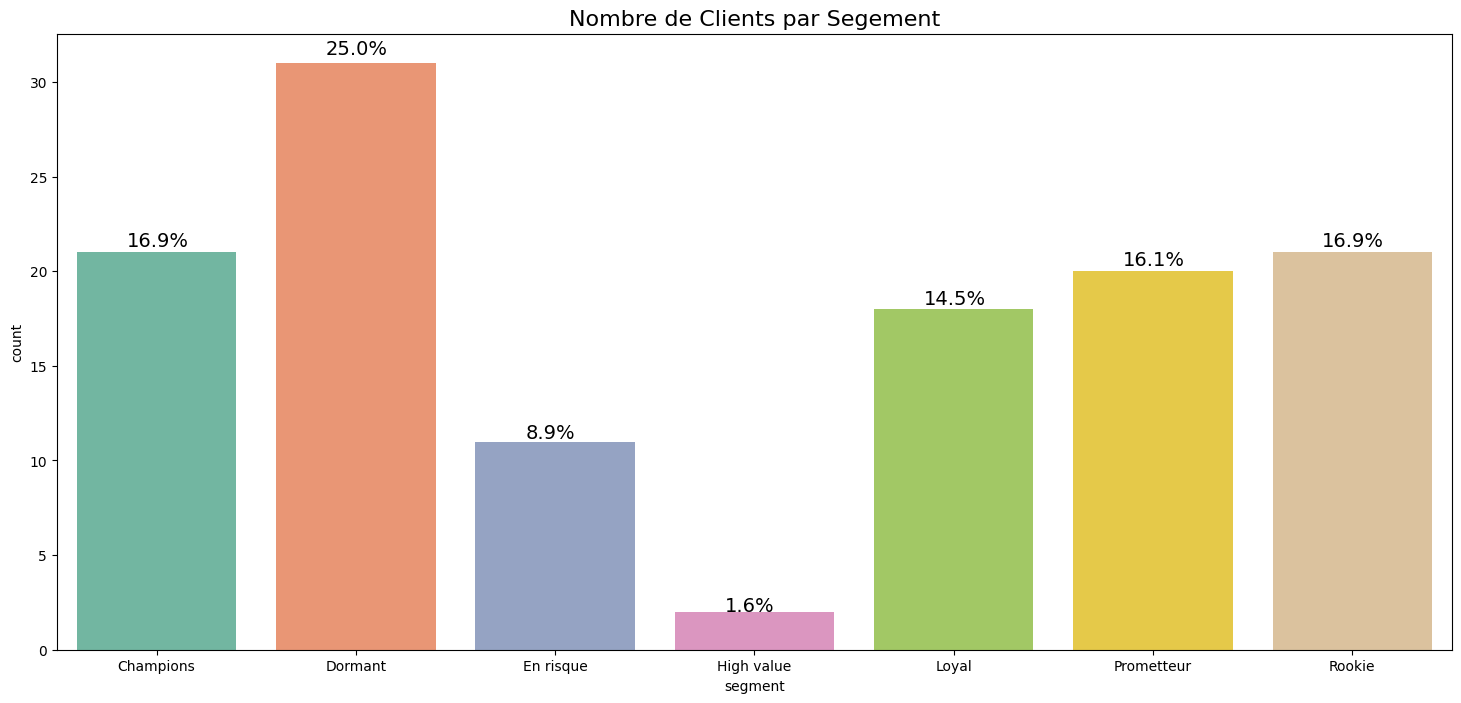

In [ ]:
plt.figure(figsize=(18,8))
ax = sns.countplot(data = pandasRfmDf,
                   x='segment',
                   palette='Set2')
total = len(pandasRfmDf.segment)

#calculer le pourcentage et l'afficher
for patch in ax.patches:
    percentage = '{:.1f}%'.format(100 * patch.get_height()/total)
    x = patch.get_x() + patch.get_width( ) / 2 - 0.15
    y = patch.get_y() + patch.get_height( ) * 1.015
    ax.annotate(percentage, (x,y), size = 14)

plt.title('Nombre de Clients par Segement',size=16)
plt.xticks(size = 10)
plt.yticks(size = 10)
plt.show()

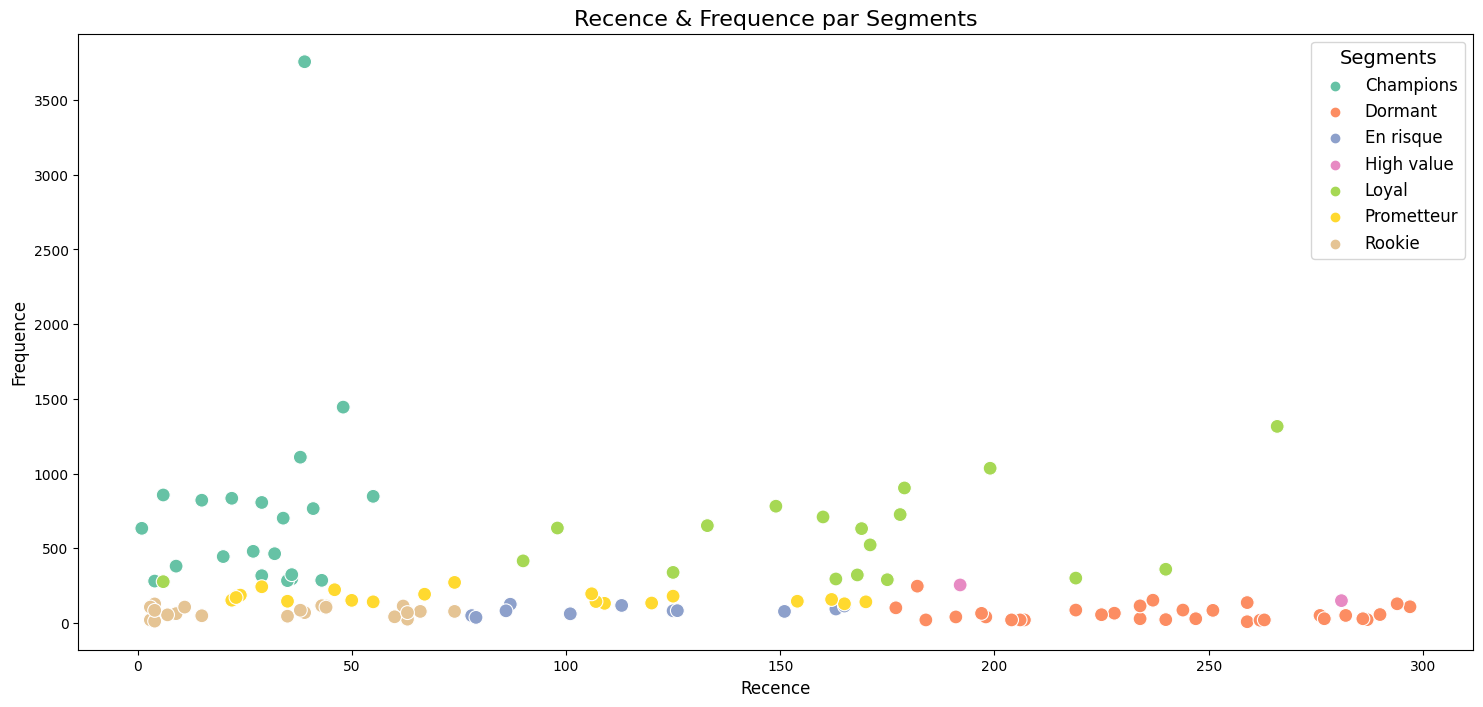

In [ ]:
plt.figure(figsize=(18, 8))
sns.scatterplot(
    data=pandasRfmDf, x="Recence", y="Frequence", hue="segment", palette='Set2', s=100
)
plt.title("Recence & Frequence par Segments", size=16)
plt.xlabel("Recence", size=12)
plt.ylabel("Frequence", size=12)
plt.xticks(size=10)
plt.yticks(size=10)
plt.legend(loc="best", fontsize=12, title="Segments", title_fontsize=14)
plt.show()

In [ ]:

# Om simule qu'on fait les analyses le jours apres la derniere transactions
today = datetime(2022,4,1)
rowsRdd = rfmRdd.map(lambda l: Row(
    index = l[0],
    date = l[1],
    customer = l[3],
    totalPrice = float(l[9])
))
groupedRdd = rowsRdd.groupBy(lambda row: row.customer)\
    .mapValues(lambda rows: (
        (today - max([row.date for row in rows])).days,
        len(set(row.index for row in rows)),
        sum(row.totalPrice for row in rows)
    ))
# les elements sont groupe par client  
groupedRdd.take(2)

,CUSTOMER,recency,frequency,monetary
0,AANCHOL,303,9,26065.00
1,ABBI COLLECTION,99,142,83628.00
2,ABDUL RAHMAN(SINGAPORE),150,196,114272.00
3,ADDVEN SOLUTIONS PRIVATE LIMITED,207,94,72456.00
4,AJS INDIAN BOUTIQUE,27,10,8368.75
